In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
StudentID,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Gender,Male,Female,Male,Male,Male,Female,Male,Male,Male,Female,...,Female,Male,Male,Female,Male,Male,Male,Female,Male,Female
Age,24,22,22,24,18,20,19,18,19,24,...,23,21,18,22,24,22,23,20,22,24
StudyHoursPerWeek,37,37,10,10,19,17,21,14,9,1,...,4,26,29,34,23,37,11,6,18,21
AttendanceRate,90.75,74.9,53.36,70.26,74.87,86.01,55.33,57.0,63.18,63.32,...,98.65,79.01,62.71,76.09,67.13,76.61,56.29,56.64,57.18,96.99
GPA,3.47,2.32,2.38,3.46,2.31,2.47,3.93,2.51,3.32,3.96,...,3.45,2.21,2.45,3.41,2.11,2.97,3.2,3.2,2.05,2.64
Major,Arts,Education,Business,Science,Education,Business,Arts,Education,Business,Engineering,...,Engineering,Arts,Education,Engineering,Business,Science,Science,Science,Business,Engineering
PartTimeJob,Yes,No,No,Yes,Yes,Yes,No,No,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,No
ExtraCurricularActivities,No,No,No,No,No,No,No,No,No,Yes,...,Yes,Yes,No,No,Yes,No,No,Yes,Yes,No


In [4]:
#find null values(missing values) of each col:
data.isnull().sum()


StudentID                    0
Gender                       0
Age                          0
StudyHoursPerWeek            0
AttendanceRate               0
GPA                          0
Major                        0
PartTimeJob                  0
ExtraCurricularActivities    0
dtype: int64

In [5]:
#Descriptive Statistics
data.describe().T



,count,mean,std,min,25%,50%,75%,max
StudentID,500.0,250.50000,144.481833,1.00,125.7500,250.50,375.25,500.00
Age,500.0,20.95600,2.000517,18.00,19.0000,21.00,23.00,24.00
StudyHoursPerWeek,500.0,19.87600,11.471347,1.00,10.0000,20.50,30.00,39.00
AttendanceRate,500.0,74.99038,14.565917,50.01,62.6075,75.73,87.22,99.97
GPA,500.0,2.98516,0.563620,2.00,2.4875,3.00,3.48,3.99


In [ ]:
data.duplicated().sum()


np.int64(0)

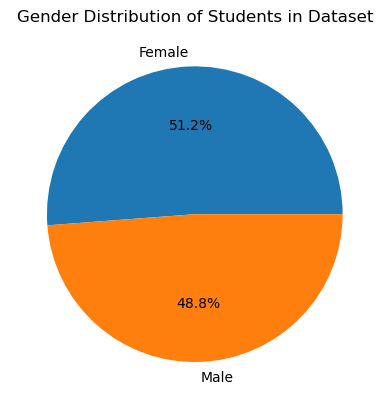

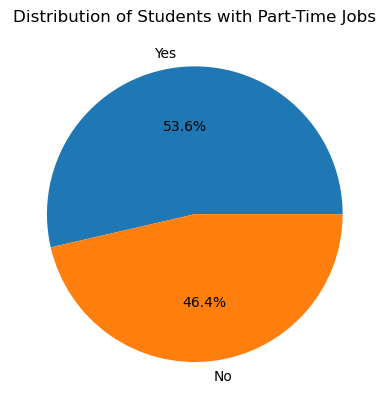

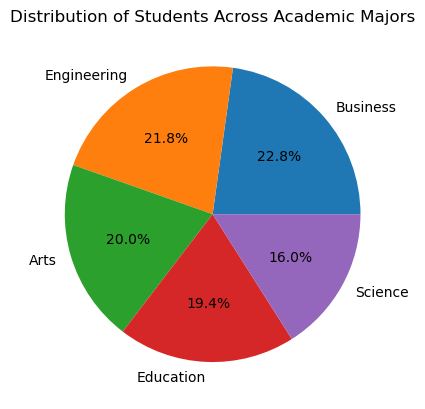

In [ ]:
""" 

-----Extract Patterns----- 
1. Gender Distribution of Students in Dataset
2. Distribution of Students with Part-Time Jobs
3. Distribution of Students Across Academic Majors
 

"""


# Gender Distribution of Students in Dataset
gender_count = data['Gender'].value_counts()

plt.figure()
plt.pie(gender_count, labels=gender_count.index, autopct='%1.1f%%')
plt.title("Gender Distribution of Students in Dataset")
plt.show()

# Distribution of Students with Part-Time Jobs
job_count = data['PartTimeJob'].value_counts()

plt.figure()
plt.pie(job_count, labels=job_count.index, autopct='%1.1f%%')
plt.title("Distribution of Students with Part-Time Jobs")
plt.show()

# Distribution of Students Across Academic Majors
major_count = data['Major'].value_counts()

plt.figure()
plt.pie(major_count, labels=major_count.index, autopct='%1.1f%%')
plt.title("Distribution of Students Across Academic Majors")
plt.show()


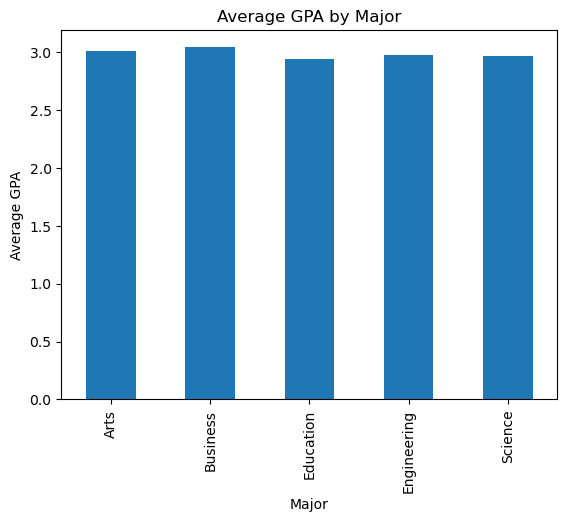

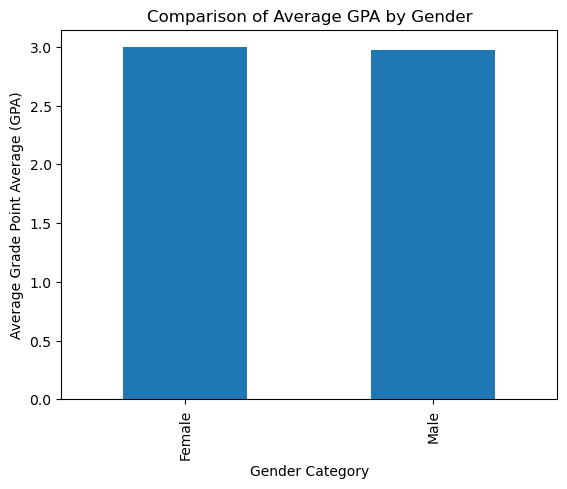

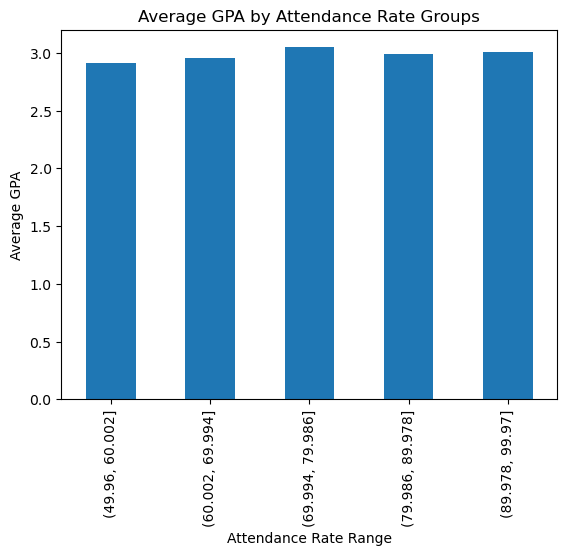

In [8]:
"""  
------insights supporting------

1. Supporting Insight from Average GPA by Major =

        Some majors show higher average GPA than others.
        This insight supports decisions to give extra academic help to weaker majors.


2. Supporting Insight from Average GPA by Gender =

        Male and female students have almost similar GPA.
        This insight supports fair academic policies because performance is balanced.

3. Supporting Insight from Attendance vs GPA

        Students with higher attendance have better GPA.
        this insight supports the decision to encourage better attendance to improve performance.
        
"""


#Average GPA by Major

avg_gpa_major = data.groupby('Major')['GPA'].mean()

plt.figure()
avg_gpa_major.plot(kind='bar')
plt.title("Average GPA by Major")
plt.xlabel("Major")
plt.ylabel("Average GPA")
plt.show()

#Comparison of Average GPA by Gender
avg_gpa_gender = data.groupby('Gender')['GPA'].mean()

plt.figure()
avg_gpa_gender.plot(kind='bar')
plt.title("Comparison of Average GPA by Gender")
plt.xlabel("Gender Category")
plt.ylabel("Average Grade Point Average (GPA)")
plt.show()

# Average GPA by Attendance Rate Groups
attendance_gpa = data.groupby(
    pd.cut(data['AttendanceRate'], bins=5),
    observed=True
)['GPA'].mean()

plt.figure()
attendance_gpa.plot(kind='bar')
plt.title("Average GPA by Attendance Rate Groups")
plt.xlabel("Attendance Rate Range")
plt.ylabel("Average GPA")
plt.show()

In [16]:
low_gpa_students = data[data['GPA'] < 2.5]
low_gpa_students.head()

,StudentID,Gender,Age,StudyHoursPerWeek,AttendanceRate,GPA,Major,PartTimeJob,ExtraCurricularActivities,StudyGroup
1,2,Female,22,37,74.90,2.32,Education,No,No,Very High Study
2,3,Male,22,10,53.36,2.38,Business,No,No,Low Study
4,5,Male,18,19,74.87,2.31,Education,Yes,No,Medium Study
5,6,Female,20,17,86.01,2.47,Business,Yes,No,Medium Study
11,12,Male,19,4,62.54,2.04,Science,No,Yes,Low Study


In [12]:
# 4. Average GPA by Study Hours Group
data['StudyGroup'] = pd.cut(
    data['StudyHoursPerWeek'],
    bins=[0, 10, 20, 30, 50],
    labels=["Low Study", "Medium Study", "High Study", "Very High Study"]
)

avg_gpa_study = data.groupby('StudyGroup', observed=True)['GPA'].mean()
print(avg_gpa_study)


StudyGroup
Low Study          2.946547
Medium Study       2.952342
High Study         2.962774
Very High Study    3.092035
Name: GPA, dtype: float64


In [27]:
#Goal
#Find every student who needs academic support based on GPA, Attendance, and Study Hours.

"""
Decision Rule

A student is At Risk if:

    GPA < 2.5
    AttendanceRate < 70
    StudyHoursPerWeek < 10  

"""


# Create At Risk column based on decision rule
data['At_Risk'] = (
    (data['GPA'] < 2.5) &
    (data['AttendanceRate'] < 70) &
    (data['StudyHoursPerWeek'] < 10)
)

# Filter ALL at-risk students
at_risk_students = data[data['At_Risk'] == True]

# Print total counts
print("Total Students:", len(data))
print("Total At Risk Students:", len(at_risk_students))

# Display ALL at-risk students
print("\nALL At Risk Students:")
print(at_risk_students)

# Save to CSV file
#at_risk_students.to_csv("at_risk_students.csv", index=False)
#print("\nFile saved as: at_risk_students.csv")


Total Students: 500
Total At Risk Students: 23

ALL At Risk Students:
     StudentID  Gender  Age  StudyHoursPerWeek  AttendanceRate   GPA  \
11          12    Male   19                  4           62.54  2.04   
33          34  Female   19                  2           56.75  2.22   
118        119  Female   18                  7           54.43  2.35   
139        140    Male   23                  4           56.22  2.46   
188        189    Male   21                  6           64.07  2.34   
211        212    Male   20                  2           58.02  2.13   
213        214    Male   18                  2           61.93  2.45   
217        218    Male   19                  9           59.46  2.48   
235        236  Female   18                  1           68.83  2.28   
269        270    Male   21                  6           57.95  2.04   
291        292    Male   22                  5           66.04  2.44   
302        303    Male   23                  5           54.56  2.

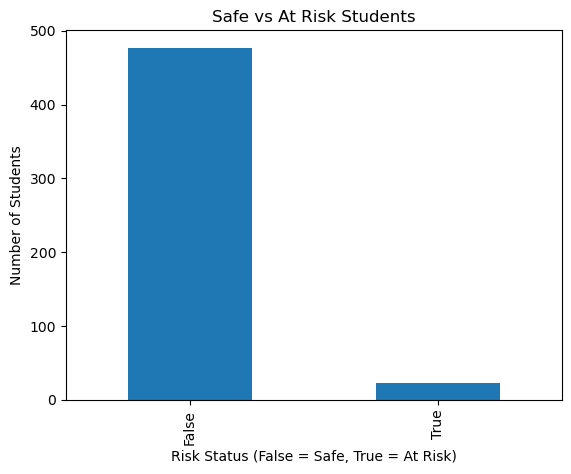

In [ ]:
# Risk Level By Graph
risk_counts = data['At_Risk'].value_counts()

plt.figure()
risk_counts.plot(kind='bar')
plt.title("Safe vs At Risk Students")
print()
plt.xlabel("Risk Status (False = Safe, True = At Risk)")
plt.ylabel("Number of Students")
plt.show()

#Insight Supporting Decision-Making

# The analysis highlights all students with low GPA,
#low attendance, and limited study hours, 
#allowing institutions to provide personalized academic support and improve overall performance.